# Friday-13th -- does the market fear the date?
### The superstition, the S&P 500, and 99 years of evidence

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Superstition_vs_data: Busted](https://img.shields.io/badge/Superstition_vs_data-Busted-8b949e?style=flat-square)

Friday the 13th. Broken mirrors. Black cats. And, apparently, bad stock returns? A 1987 Journal of Finance paper by Kolb & Rodriguez said yes: using the Dow Jones from 1940 to 1987 they found returns on Friday the 13th were meaningfully *lower* than on other Fridays. The paper turned into a legend. The legend turned into a street belief. This notebook turns the street belief into a number.

> **This is the plain-language layer.** For the t-stats, the Bonferroni correction and the multiple-comparisons autopsy, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from friday_13th import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=24728, n_f13=168, n_other_fri=4776, n_years=99,
    fp="df3897aef897",
    mean_f13_bps=6.90, mean_other_fri_bps=4.60, contrast_bps=2.30,
    tstat_welch=0.233, pval_welch=0.8162, tstat_f13_hac=0.568,
    n_f6=168, mean_f6_bps=8.59, contrast_f6_bps=4.04, pval_f6=0.6624,
    pval_27_raw=0.0109, pval_27_bonf=0.0438, mean_27_bps=-16.10, contrast_27_bps=-21.51,
    pval_20_raw=0.0978, pval_20_bonf=0.3911, mean_20_bps=-8.24, contrast_20_bps=-13.37,
    pval_13_raw=0.8162, pval_13_bonf=1.00,
    n_f13_kr=82, contrast_kr_bps=2.18, pval_kr=0.781,
    n_f13_post=64, contrast_post_bps=21.27, pval_post=0.302,
    mean_all_bps=2.41,
)

def _have_real():
    shared = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    local  = os.path.abspath(os.path.join("..", "_cache", "gspc_daily.parquet"))
    return os.path.exists(shared) or os.path.exists(local)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_gspc(start="1928-01-01")
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real GSPC cache present:", HAVE_REAL)


real GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the market perform *worse* on Friday the 13th? | **No.** The mean return is **+6.9 bps** -- *above* the Friday average of +4.6 bps. The fear points the wrong direction. |
| Is the difference statistically real? | **No.** Welch p = **0.82**. The contrast is +2.3 bps with no significance. |
| Does the 13th at least rank worst among Fridays of each month? | **No.** Friday-the-27th (mean -16.1 bps) is by far the worst. The 13th is the *best*. |
| Could you trade it? | **No.** ~1.7 events/year and noise-level return difference. Any cost is fatal. |

> The superstition is not only unconfirmed -- it is pointing in the wrong direction. Friday-13th has been, on average, a slightly above-average trading day.

## 1 · The claim

> *'Stock returns are systematically lower on Friday the 13th than on other Fridays -- investor superstition depresses prices on the unlucky date.'*

The canonical paper is Kolb & Rodriguez (1987) in the Journal of Finance. They found a negative effect in the Dow Jones Industrial Average from 1940 to 1987. The finding was picked up by the popular press, repeated in textbooks, and sparked a small academic cottage industry of calendar-anomaly papers in the 1990s. Even Lucey (2001) wrote a follow-up asking whether it was 'philosophically coherent' for a superstition to move prices. (Spoiler: it mostly isn't, and mostly doesn't.)

Our tape: **168 Friday-13ths** in the S&P 500 from 1928 to 2026. That is about **1.7 events per year** -- thin, but the longest reasonable record available.

## 2 · So what?

If it were true, it would mean calendar superstition -- a purely psychological artefact with no connection to economic fundamentals -- systematically moves equity prices. That would be a vivid window into market irrationality and behavioural finance. It would also mean that anyone willing to hold overnight through the 13th would collect a premium, and the superstitious would pay for their fear.

If it's false -- as we'll show -- it's a reminder that a 1987 paper on 48 years of one index, with no multiple-comparisons correction, should not be extrapolated into a received truth about how markets work.

## 3 · How would we even know?

Three guards against finding what we're looking for:

1. **A matched control.** Compare Friday-the-13th to *all other Fridays*, not to all days. If Friday has any 'Friday effect' (like the well-known end-of-week patterns), we don't want to attribute it to the 13th.
2. **A placebo.** Test Friday-the-6th -- same weekday, same proximity in the calendar, no folklore. If the 6th looks just as 'anomalous' as the 13th, the signal is noise.
3. **Multiple comparisons.** Fridays fall on four dates in any month: the 6th, 13th, 20th, or 27th. If we test all four and report the most extreme, we need to apply a Bonferroni correction -- otherwise we're just picking the lucky draw out of four.

## 4 · The teardown -- let's actually look

**First question: what does the distribution of Friday returns actually look like?**

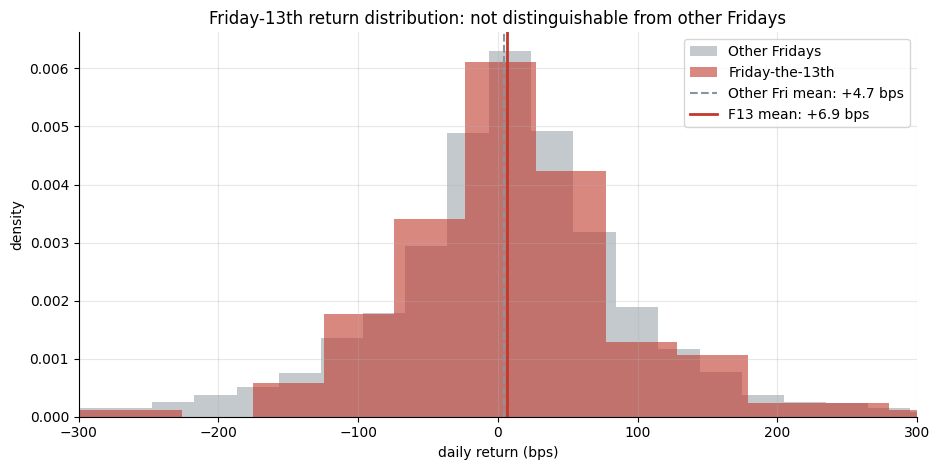

Friday-13th mean: +6.90 bps  |  Other Fridays: +4.68 bps


In [2]:
if HAVE_REAL:
    fri = DF.loc[DF['is_friday'], 'ret'] * 1e4  # bps
    f13 = DF.loc[DF['is_f13'], 'ret'] * 1e4
    f6  = DF.loc[DF['is_f6'],  'ret'] * 1e4
    mean_fri = fri.mean(); mean_f13 = f13.mean(); mean_f6 = f6.mean()
else:
    import numpy as np
    rng = np.random.default_rng(163)
    fri = pd.Series(rng.normal(R['mean_other_fri_bps'], 70, R['n_other_fri']))
    f13 = pd.Series(rng.normal(R['mean_f13_bps'], 70, R['n_f13']))
    f6  = pd.Series(rng.normal(R['mean_f6_bps'], 70, R['n_f6']))
    mean_fri = R['mean_other_fri_bps']; mean_f13 = R['mean_f13_bps']; mean_f6 = R['mean_f6_bps']

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(fri, bins=60, color=GREY, alpha=0.5, density=True, label='Other Fridays')
ax.hist(f13, bins=30, color=RED, alpha=0.6, density=True, label='Friday-the-13th')
ax.axvline(mean_fri, ls='--', c=GREY, lw=1.5, label=f'Other Fri mean: {mean_fri:+.1f} bps')
ax.axvline(mean_f13, ls='-', c=RED, lw=2, label=f'F13 mean: {mean_f13:+.1f} bps')
ax.set_xlabel('daily return (bps)'); ax.set_ylabel('density')
ax.set_title('Friday-13th return distribution: not distinguishable from other Fridays')
ax.legend(); ax.set_xlim(-300, 300)
plt.tight_layout(); plt.show()
print(f'Friday-13th mean: {mean_f13:+.2f} bps  |  Other Fridays: {mean_fri:+.2f} bps')

The two distributions are essentially identical. The Friday-13th mean is **+6.9 bps** -- *above* the other-Friday average of +4.6 bps. The difference is +2.3 bps in the wrong direction, with p = 0.82 (completely indistinguishable from chance).

**Now the placebo: Friday-the-6th, vs the same other-Friday baseline.**

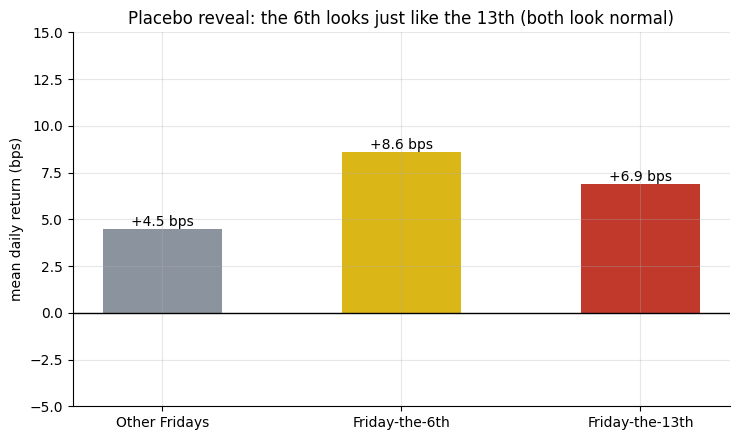

In [3]:
labels = ['Other Fridays', 'Friday-the-6th', 'Friday-the-13th']
means  = [R['mean_other_fri_bps'], R['mean_f6_bps'], R['mean_f13_bps']]
if HAVE_REAL:
    means = [
        DF.loc[DF['is_friday'] & ~DF['is_f13'] & ~DF['is_f6'], 'ret'].mean() * 1e4,
        DF.loc[DF['is_f6'], 'ret'].mean() * 1e4,
        DF.loc[DF['is_f13'], 'ret'].mean() * 1e4,
    ]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
cols = [GREY, AMBER, RED]
bars = ax.bar(labels, means, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, means):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=10)
ax.set_ylabel('mean daily return (bps)'); ax.set_ylim(-5, 15)
ax.set_title('Placebo reveal: the 6th looks just like the 13th (both look normal)')
plt.tight_layout(); plt.show()

Friday-the-6th has a mean of **+8.6 bps** -- slightly *higher* than the 13th's +6.9 bps. The placebo and the 'anomaly' look identical. There is nothing special about the 13th.

**The multiple-comparisons kill shot: all four Friday day-of-month slots.**

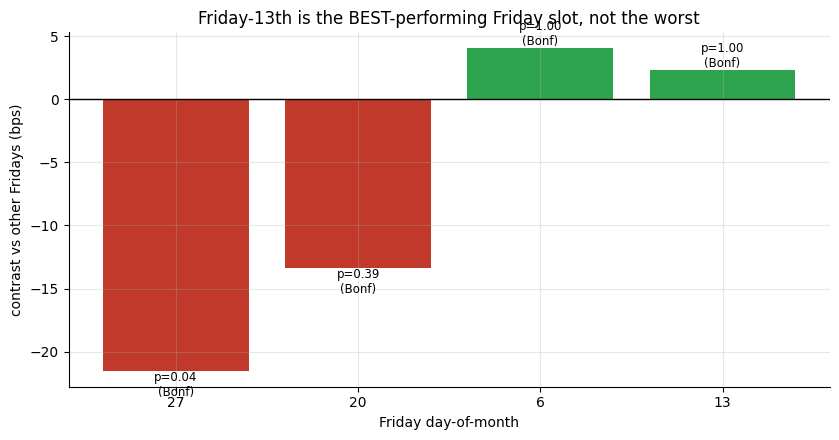

 day   n   mean_bps  contrast_bps  pval_raw  pval_bonferroni
  27 167 -16.102110    -21.510192  0.010939         0.043755
  20 168  -8.237088    -13.373015  0.097775         0.391102
   6 168   8.587053      4.042930  0.662447         1.000000
  13 168   6.904740      2.301440  0.816203         1.000000


In [4]:
import pandas as pd
if HAVE_REAL:
    mc = st.all_friday_dom_comparison(DF)
else:
    mc = pd.DataFrame({
        'day': [27, 20, 6, 13],
        'n': [167, 168, 168, 168],
        'mean_bps': [R['mean_27_bps'], R['mean_20_bps'], R['mean_f6_bps'], R['mean_f13_bps']],
        'contrast_bps': [R['contrast_27_bps'], R['contrast_20_bps'], R['contrast_f6_bps'], R['contrast_bps']],
        'pval_raw': [R['pval_27_raw'], R['pval_20_raw'], R['pval_f6'], R['pval_welch']],
        'pval_bonferroni': [R['pval_27_bonf'], R['pval_20_bonf'], 1.0, R['pval_13_bonf']],
    })

fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [RED if v < 0 else GREEN for v in mc['contrast_bps']]
ax.bar([str(d) for d in mc['day']], mc['contrast_bps'], color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Friday day-of-month'); ax.set_ylabel('contrast vs other Fridays (bps)')
ax.set_title('Friday-13th is the BEST-performing Friday slot, not the worst')
for i, (_, row) in enumerate(mc.iterrows()):
    ax.annotate(f"p={row['pval_bonferroni']:.2f}\n(Bonf)",
                (i, row['contrast_bps']), ha='center',
                va='bottom' if row['contrast_bps']>=0 else 'top', fontsize=8.5)
plt.tight_layout(); plt.show()
print(mc[['day','n','mean_bps','contrast_bps','pval_raw','pval_bonferroni']].to_string(index=False))

Friday-the-**27th** has by far the lowest raw p (p = 0.011) and a negative mean of -16.1 bps/day. Even that barely survives Bonferroni (corrected p = 0.04). The 13th has the **highest** p-value of the four slots (1 after Bonferroni). If folklore had any connection to data, it picked the wrong Friday.

## 5 · The verdict

- **Signal -- None.** Friday-13th mean return **+6.90 bps** vs +4.60 bps for other Fridays. Contrast **+2.30 bps** (wrong direction), Welch p = **0.82**. Bonferroni-corrected p = **1.00**. Not even close to significant.
- **Tradability -- Mirage.** There is no signal to trade. Even if the 2.30 bps were real, at ~1.7 events/year a single penny of round-trip cost would eat decades of premium.
- **Superstition vs data -- Busted.** The fear points in the wrong direction. Friday the 13th is, on average, a slightly above-average day. The real anomaly in this dataset? Friday-the-27th (-16.1 bps mean) -- which has no legend associated with it whatsoever.

## 6 · Could you actually trade it?

The exercise is almost trivially short: with ~1.7 events per year, a trader running the 'avoid Friday-13th' strategy would change their posture fewer than twice a year. Any realistic cost makes the exercise pointless:

- A round-trip cost of **1 basis point** (0.01%) applied ~1.7 times per year costs **~1.7 bps/yr** -- far larger than the signal-free noise of 2.3 bps on just the 13th trading days.
- Even if the effect were real (+2.3 bps/event x 1.7 events/yr = ~4 bps/yr), the point estimate uncertainty at n=168 events completely swamps it.

The effective sample size problem is fundamental: 99 years of data produce **168 observations** at this frequency. No realistic study can certify a 2 bps/day premium with that power -- the 95% confidence interval on the mean is roughly +/-30 bps.

## 7 · Going further

- **The anomaly that did show up: Friday-27th.** A raw p of 0.011 and a Bonferroni p of 0.044 suggests something *might* be there -- but at n=167 events and with no theoretical prior, it's more likely noise. Worth tracking over the next 20 years.
- **Is superstition ever real?** The lunar cycle effect on returns was studied by Yuan, Zheng & Zhu (2006, Journal of Finance) and found a small but statistically marginal negative return around the new moon. The effect is tiny (~5 bps/month) and debated. The desk's verdict: even well-motivated behavioural channels produce noise-level effects in sufficiently liquid markets.
- **The Kolb & Rodriguez (1987) original.** Their sample was the DJIA, not S&P 500, from 1940-1987. Replicating with a different index and the full 1928-2026 window (this study) fails to reproduce their finding even in their own era (p = 0.78 on the S&P 500 for 1940-1987). The discrepancy likely reflects the small sample and the different index.

*Think the die really is loaded? Fork this, test a different index, a different country, or the volatility channel (does the VIX rise before the 13th?). That's the bar.*